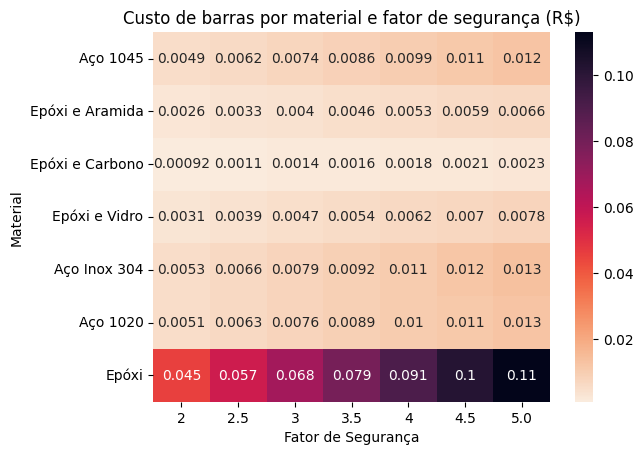

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# melhor visualização
# módulo de elasticidade (gPa), densidade (kg/m^3) e custo por quilograma(kg) (R$/kg)
materiais = {
    'Aço 1045': {'Elasticidade': 210*1e9, 'densidade': 7850, 'custo': 5.50},
    'Epóxi e Aramida': {'Elasticidade': 70*1e9, 'densidade': 1400, 'custo': 50.00},
    'Epóxi e Carbono': {'Elasticidade': 230*1e9, 'densidade': 1600, 'custo': 150.00},
    'Epóxi e Vidro': {'Elasticidade': 85*1e9, 'densidade': 2000, 'custo': 60.00},
    'Aço Inox 304': {'Elasticidade': 200*1e9, 'densidade': 8000, 'custo': 20.00},
    'Aço 1020': {'Elasticidade': 205*1e9, 'densidade': 7870, 'custo': 4.50},
    'Epóxi': {'Elasticidade': 3.5*1e9, 'densidade': 1200, 'custo': 30.00}
}

# Dados constante:
forca = 220000 # N
altura = 0.30 # m
fatores_de_seguranca = [2, 2.5, 3, 3.5, 4, 4.5, 5.0]

def calcular_custo(material, fator_seguranca):
    Elasticidade = materiais[material]['Elasticidade']  # Pa
    densidade = materiais[material]['densidade']  # kg/m^3
    custo_por_kg = materiais[material]['custo']  # R$/kg

    # valor máximo de tensão que um material resiste sem danos
    tensao_admissivel = Elasticidade / fator_seguranca

    area = forca / tensao_admissivel

    volume = area * altura

    massa = volume * densidade

    return massa

    custo_total = massa * custo_por_kg

    return custo_total

# Gerar a matriz de custos
custos = np.zeros((len(materiais), len(fatores_de_seguranca)))

for i, material in enumerate(materiais):
    for j, fator_seguranca in enumerate(fatores_de_seguranca):
        custos[i, j] = calcular_custo(material, fator_seguranca)

# Visualizar o mapa de calor
sns.heatmap(custos, annot=True, xticklabels=fatores_de_seguranca, yticklabels=materiais.keys(), cmap="rocket_r")
plt.title("Custo de barras por material e fator de segurança (R$)")
plt.xlabel("Fator de Segurança")
plt.ylabel("Material")
plt.show()